In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# feature scaling 
# 1. standardization >> mu= 0, sigma = 1
# 2. normalization >> min-max scaling >> 0-1
# 3. unit vector >> 0-1

In [3]:
df = sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


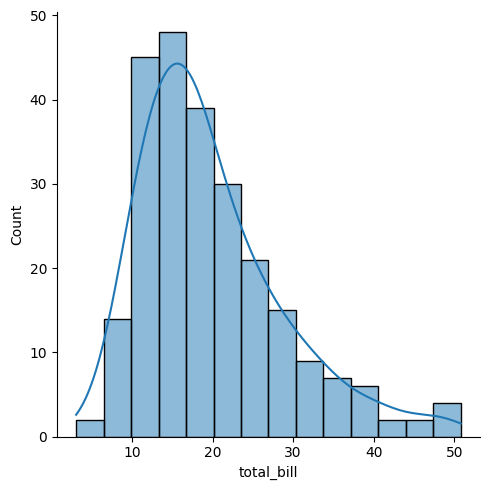

In [4]:
sns.displot(df["total_bill"], kde = True)

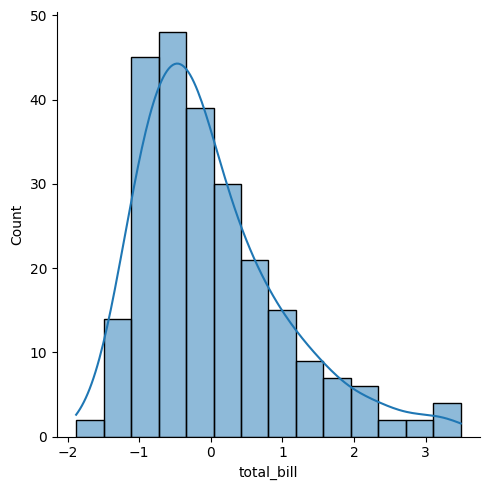

In [ ]:
# standardization (using sklearn)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[["total_bill"]])  
scaled_data = pd.DataFrame(scaled_data, columns = ["total_bill"])
scaled_data.describe()
sns.displot(scaled_data["total_bill"], kde = True)


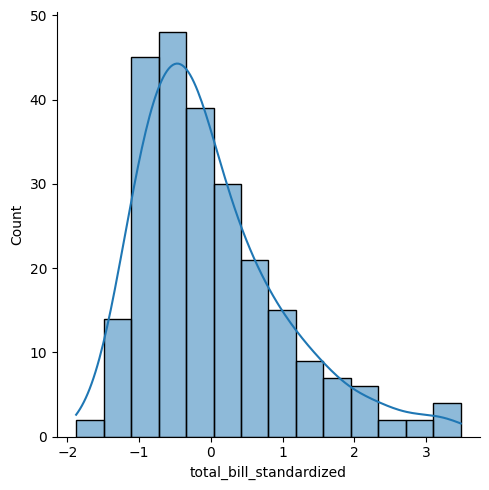

In [6]:
# standardization 
# lets calculae mean and std
mean = df["total_bill"].mean()
std = df["total_bill"].std()

# standardization formula
df["total_bill_standardized"] = (df["total_bill"] - mean) / std
df[["total_bill", "total_bill_standardized"]].head()
sns.displot(df["total_bill_standardized"], kde = True)


In [7]:
# we can also use for loop to standardize multiple columns at once
std_data = []
for i in list(df["total_bill"]):
    zscore = (i - mean)/std
    std_data.append(zscore)
df["total_bill_standardized_loop"] = std_data
df[["total_bill", "total_bill_standardized", "total_bill_standardized_loop"]].head()

,total_bill,total_bill_standardized,total_bill_standardized_loop
0,16.99,-0.314066,-0.314066
1,10.34,-1.061054,-1.061054
2,21.01,0.137497,0.137497
3,23.68,0.437416,0.437416
4,24.59,0.539635,0.539635


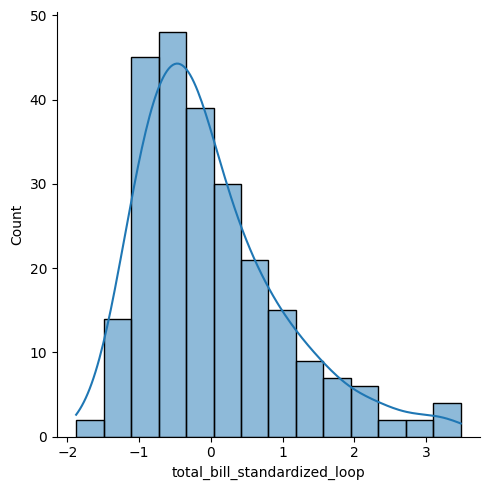

In [8]:
sns.displot(df["total_bill_standardized_loop"], kde = True)

In [9]:
# normalization (min-max scaling)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[["total_bill", "tip"]])
scaled_data = pd.DataFrame(scaled_data, columns = ["total_bill", "tip"])
scaled_data.describe()

,total_bill,tip
count,244.000000,244.000000
mean,0.350145,0.222031
std,0.186477,0.153738
min,0.000000,0.000000
25%,0.215281,0.111111
50%,0.308442,0.211111
75%,0.441087,0.284722
max,1.000000,1.000000


In [10]:
scaled_data

,total_bill,tip
0,0.291579,0.001111
1,0.152283,0.073333
2,0.375786,0.277778
3,0.431713,0.256667
4,0.450775,0.290000
...,...,...
239,0.543779,0.546667
240,0.505027,0.111111
241,0.410557,0.111111
242,0.308965,0.083333


In [14]:
# unit vector scaling 
from sklearn.preprocessing import Normalizer
unit_vector_scaler = Normalizer()
scaled_data = unit_vector_scaler.fit_transform(df[["total_bill", "tip"]])
scaled_data = pd.DataFrame(scaled_data, columns = ["total_bill", "tip"])
scaled_data.describe()


,total_bill,tip
count,244.000000,244.000000
mean,0.985882,0.157737
std,0.013875,0.054555
min,0.815250,0.035616
25%,0.982158,0.128064
50%,0.988234,0.152949
75%,0.991766,0.188059
max,0.999366,0.579109
